# A GPU-accelerated conformer workflow with nvMolKit

*Draft guest post from Kevin Boyd at NVIDIA.*

[nvMolKit](https://github.com/NVIDIA-BioNeMo/nvMolKit) provides GPU-accelerated,
batched implementations of common RDKit operations. Here we compare a practical
three-stage 3D workflow:

1. generate 50 conformers per molecule with ETKDGv3;
2. minimize every conformer with MMFF94;
3. calculate all-pairs torsion fingerprint deviation (TFD) matrices.

nvMolKit 0.6 adds the FIRE minimizer as an alternative to its BFGS minimizer,
so we will include both GPU options. The CPU comparison uses 16 threads wherever
the RDKit API exposes a thread-count option.

## Imports and configuration

The results below use official binary installations of RDKit and nvMolKit; no
locally built libraries are loaded. The benchmark machine has an NVIDIA GeForce
RTX 5080 and an AMD Ryzen 9 9950X.

The Enamine REAL input file is not included in this repository. Change
`smi_file` to point at the [Enamine REAL 10.4M sample](https://enamine.net/compound-collections/real-compounds/real-database-subsets).

In [1]:
from pathlib import Path
from time import perf_counter
import importlib.metadata
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem, rdBase
from rdkit.Chem import AllChem, rdDistGeom, TorsionFingerprints

from nvmolkit.embedMolecules import EmbedMolecules
from nvmolkit.mmffOptimization import MMFFOptimizeMoleculesConfs
from nvmolkit.tfd import GetTFDMatrices
from nvmolkit.types import FireOptions, HardwareOptions

print("Python:", platform.python_version())
print("RDKit:", rdBase.rdkitVersion)
print("nvMolKit:", importlib.metadata.version("nvmolkit"))
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("nvMolKit loaded from:", importlib.util.find_spec("nvmolkit").origin)

Python: 3.14.4
RDKit: 2026.03.5
nvMolKit: 0.6.0
PyTorch: 2.13.0+cu130
GPU: NVIDIA GeForce RTX 5080
nvMolKit loaded from: /home/kevin/programs/miniforge3/envs/nvmolkit_iface_py3.14/lib/python3.14/site-packages/nvmolkit/__init__.py


In [2]:
n_mols = 500
n_confs = 50
n_cpu_threads = 16
max_mmff_iters = 200
fire_iters = 600
random_seed = 42

smi_file = Path("../data/enamine_real_10M.csxmiles")
if not smi_file.exists():
    smi_file = Path("/home/kevin/data/enamine_real_10M.csxmiles")
assert smi_file.exists(), f"Enamine REAL file not found: {smi_file}"

hardware_options = HardwareOptions(preprocessingThreads=n_cpu_threads, gpuIds=[0])

## Loading molecules

Parsing, hydrogen addition, MMFF parameter checking, and molecule copying are
preparation steps and are not included in any timing. We take the first 500
parseable Enamine REAL molecules for which RDKit has complete MMFF parameters.

In [3]:
mols = []
with smi_file.open() as inf:
    next(inf)
    for line in inf:
        mol = Chem.MolFromSmiles(line.split("\t", 1)[0])
        if mol is None:
            continue
        mol = Chem.AddHs(mol)
        if not AllChem.MMFFHasAllMoleculeParams(mol):
            continue
        mols.append(mol)
        if len(mols) == n_mols:
            break

print(f"Loaded {len(mols):,} molecules")
print(f"Median heavy atoms: {np.median([m.GetNumHeavyAtoms() for m in mols]):.0f}")

Loaded 500 molecules
Median heavy atoms: 12


## ETKDG conformer generation

Both paths use ETKDGv3, random-coordinate initialization, and the same seed.
RDKit parallelizes the 50 conformers of each molecule over 16 CPU threads;
nvMolKit processes the complete molecule batch on the GPU and uses 16 CPU
preprocessing threads.

Small untimed calls initialize both backends before measurement.

In [4]:
rd_params = rdDistGeom.ETKDGv3()
rd_params.useRandomCoords = True
rd_params.randomSeed = random_seed
rd_params.numThreads = n_cpu_threads

nv_params = rdDistGeom.ETKDGv3()
nv_params.useRandomCoords = True
nv_params.randomSeed = random_seed

rd_warmup = Chem.Mol(mols[0])
rdDistGeom.EmbedMultipleConfs(rd_warmup, numConfs=2, params=rd_params)
nv_warmup = [Chem.Mol(m) for m in mols[:4]]
EmbedMolecules(nv_warmup, nv_params, confsPerMolecule=2, hardwareOptions=hardware_options)
torch.cuda.synchronize()

In [5]:
rdkit_embedded = [Chem.Mol(m) for m in mols]
t0 = perf_counter()
for mol in rdkit_embedded:
    rdDistGeom.EmbedMultipleConfs(mol, numConfs=n_confs, params=rd_params)
rdkit_embed_time = perf_counter() - t0

rdkit_n_confs = sum(m.GetNumConformers() for m in rdkit_embedded)
print(f"RDKit ETKDG: {rdkit_embed_time:.2f} s ({rdkit_n_confs:,} conformers)")

RDKit ETKDG: 5.67 s (25,000 conformers)


In [6]:
nvmolkit_embedded = [Chem.Mol(m) for m in mols]
t0 = perf_counter()
EmbedMolecules(
    nvmolkit_embedded,
    nv_params,
    confsPerMolecule=n_confs,
    hardwareOptions=hardware_options,
)
torch.cuda.synchronize()
nvmolkit_embed_time = perf_counter() - t0

nvmolkit_n_confs = sum(m.GetNumConformers() for m in nvmolkit_embedded)
print(f"nvMolKit ETKDG: {nvmolkit_embed_time:.2f} s ({nvmolkit_n_confs:,} conformers)")

nvMolKit ETKDG: 5.19 s (25,000 conformers)


## MMFF94 minimization: RDKit, nvMolKit BFGS, and nvMolKit FIRE

For a fair optimizer and energy comparison, all minimizers start from identical
coordinates: clones of the nvMolKit-generated conformers. Force-field
construction is included in each timing. RDKit and nvMolKit BFGS use 200
iterations. FIRE uses 600 iterations and a gradient tolerance of $10^{-4}$.
The appendix explains how that iteration budget was selected.

In [7]:
rdkit_ff_mols = [Chem.Mol(m) for m in nvmolkit_embedded]
nvmolkit_bfgs_mols = [Chem.Mol(m) for m in nvmolkit_embedded]
nvmolkit_fire_mols = [Chem.Mol(m) for m in nvmolkit_embedded]

t0 = perf_counter()
rdkit_ff_results = [
    AllChem.MMFFOptimizeMoleculeConfs(
        mol,
        numThreads=n_cpu_threads,
        maxIters=max_mmff_iters,
        nonBondedThresh=100.0,
        ignoreInterfragInteractions=True,
    )
    for mol in rdkit_ff_mols
]
rdkit_mmff_time = perf_counter() - t0
rdkit_status = np.array([status for result in rdkit_ff_results for status, _ in result])
rdkit_energies = np.array([energy for result in rdkit_ff_results for _, energy in result])
print(f"RDKit MMFF: {rdkit_mmff_time:.2f} s; {(rdkit_status == 0).sum():,}/{len(rdkit_status):,} converged")

RDKit MMFF: 5.97 s; 23,277/25,000 converged


In [8]:
t0 = perf_counter()
nvmolkit_bfgs_results = MMFFOptimizeMoleculesConfs(
    nvmolkit_bfgs_mols,
    maxIters=200,
    nonBondedThreshold=100.0,
    ignoreInterfragInteractions=True,
    hardwareOptions=hardware_options,
    minimizerKind="BFGS",
)
torch.cuda.synchronize()
nvmolkit_bfgs_time = perf_counter() - t0
print(f"nvMolKit BFGS (200 iterations): {nvmolkit_bfgs_time:.2f} s")

nvMolKit BFGS (200 iterations): 4.27 s


In [9]:
fire_options = FireOptions()
fire_options.gradTol = 1e-4

t0 = perf_counter()
nvmolkit_fire_results = MMFFOptimizeMoleculesConfs(
    nvmolkit_fire_mols,
    maxIters=fire_iters,
    nonBondedThreshold=100.0,
    ignoreInterfragInteractions=True,
    hardwareOptions=hardware_options,
    minimizerKind="FIRE",
    fireOptions=fire_options,
)
torch.cuda.synchronize()
nvmolkit_fire_time = perf_counter() - t0
print(f"nvMolKit FIRE ({fire_iters} iterations): {nvmolkit_fire_time:.2f} s")

nvMolKit FIRE (600 iterations): 2.24 s

## Torsion fingerprint deviation matrices

There are $50\times49/2=1225$ pairwise TFD values per molecule. The same
BFGS-minimized coordinates are passed to both implementations after removing
explicit hydrogens. TFD is invariant to global molecular rotation and
translation and captures changes in the rotatable-bond torsions of the
conformer ensemble.

In [10]:
rdkit_tfd_mols = [Chem.RemoveHs(Chem.Mol(m)) for m in nvmolkit_bfgs_mols]
nvmolkit_tfd_mols = [Chem.Mol(m) for m in rdkit_tfd_mols]

t0 = perf_counter()
nvmolkit_tfd_results = GetTFDMatrices(nvmolkit_tfd_mols, return_type="numpy")
torch.cuda.synchronize()
nvmolkit_tfd_time = perf_counter() - t0

t0 = perf_counter()
rdkit_tfd_results = [
    TorsionFingerprints.GetTFDMatrix(mol, useWeights=True, maxDev="equal")
    for mol in rdkit_tfd_mols
]
rdkit_tfd_time = perf_counter() - t0

tfd_abs_differences = np.concatenate([
    np.abs(np.asarray(rd) - np.asarray(nv))
    for rd, nv in zip(rdkit_tfd_results, nvmolkit_tfd_results)
    if len(rd)
])
print(f"RDKit TFD: {rdkit_tfd_time:.2f} s")
print(f"nvMolKit TFD: {nvmolkit_tfd_time:.3f} s")
print(f"TFD values within 0.01: {np.mean(tfd_abs_differences <= 0.01):.2%}")
pd.Series(tfd_abs_differences).quantile([0.5, 0.9, 0.99, 0.999, 1.0]).rename("absolute TFD difference")

RDKit TFD: 0.87 s
nvMolKit TFD: 0.010 s
TFD values within 0.01: 99.14%


0.500    2.593648e-07
0.900    6.718258e-06
0.990    2.268800e-04
0.999    6.068471e-01
1.000    7.962908e-01
Name: absolute TFD difference, dtype: float64

## Performance summary

The total is the sum of the three measured stages. Preparation, molecule
copying, warmup, validation re-scoring, and plotting are excluded.

In [11]:
timings = pd.DataFrame(
    {
        "RDKit": [rdkit_embed_time, rdkit_mmff_time, rdkit_tfd_time],
        "nvMolKit BFGS 200": [nvmolkit_embed_time, nvmolkit_bfgs_time, nvmolkit_tfd_time],
        "nvMolKit FIRE 600": [nvmolkit_embed_time, nvmolkit_fire_time, nvmolkit_tfd_time],
    },
    index=["ETKDG", "MMFF94", "TFD"],
)
timings.loc["Total"] = timings.sum()
timings.loc["Speedup vs RDKit"] = timings.loc["Total", "RDKit"] / timings.loc["Total"]
timings

,RDKit,nvMolKit BFGS 200,nvMolKit FIRE 600
ETKDG,5.672134,5.191850,5.191850
MMFF94,5.967099,4.269059,2.240351
TFD,0.871457,0.010324,0.010324
Total,12.510689,9.471233,7.442524
Speedup vs RDKit,1.000000,1.320915,1.680974


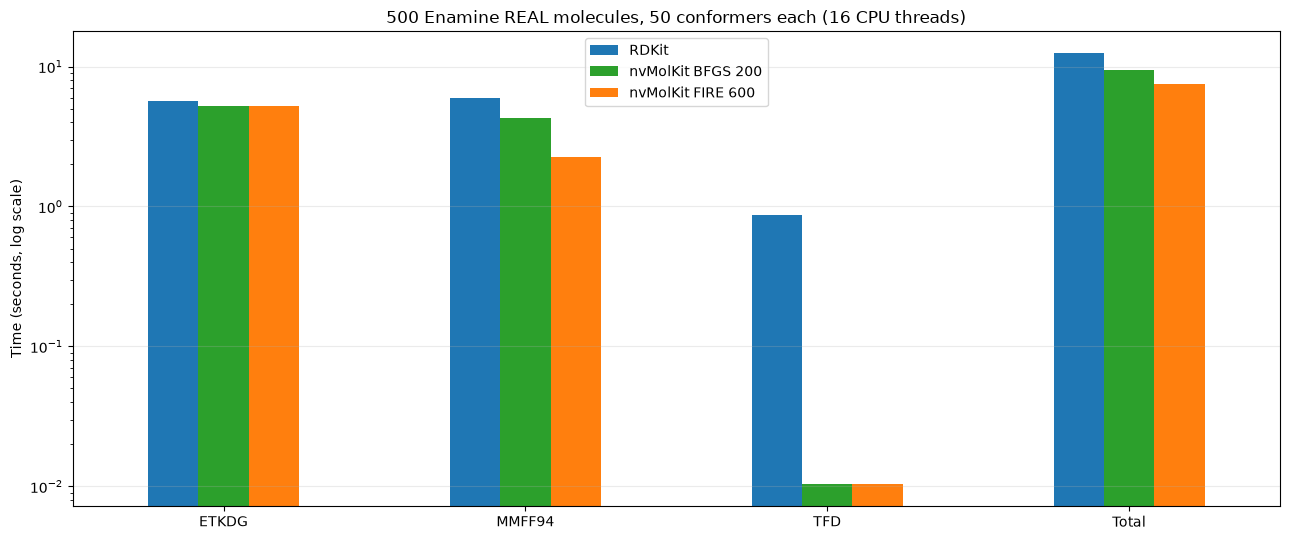

nvMolKit BFGS 200 workflow speedup: 1.32x
nvMolKit FIRE 600 workflow speedup: 1.68x


In [12]:
plot_timings = timings.loc[["ETKDG", "MMFF94", "TFD", "Total"]]
ax = plot_timings.plot.bar(
    figsize=(13, 5.5), logy=True,
    color=["#1f77b4", "#2ca02c", "#ff7f0e"],
)
ax.set_ylabel("Time (seconds, log scale)")
ax.set_title(f"500 Enamine REAL molecules, 50 conformers each ({n_cpu_threads} CPU threads)")
ax.set_xticklabels(plot_timings.index, rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

for label in timings.columns[1:]:
    print(f"{label} workflow speedup: {timings.loc['Speedup vs RDKit', label]:.2f}x")

## Conclusions

This example is deliberately an end-to-end workflow rather than a single-kernel
microbenchmark. ETKDG and MMFF dominate the total time; pairwise TFD is a small
part of the GPU path even though it produces 612,500 values.

The GPU workflow is shown with both BFGS at 200 iterations and FIRE at 600
iterations. Runtime alone is not enough for selecting a geometry optimizer;
the appendix describes the separate energy-distribution analysis used to choose
the FIRE iteration budget.

See the [nvMolKit documentation](https://nvidia-bionemo.github.io/nvMolKit/)
and [source repository](https://github.com/NVIDIA-BioNeMo/nvMolKit) for more.

## Appendix: choosing the FIRE iteration budget

The FIRE setting was selected in a separate, reproducible `fire_analysis`
repository rather than by adding a parameter scan to the timed workflow above.
That analysis uses the same 500 Enamine REAL molecules and 50 conformers per
molecule. Every optimizer starts from the same nvMolKit ETKDG coordinates.
Final BFGS and FIRE geometries are independently re-scored with RDKit MMFF94.

BFGS is a comparison point, not an absolute answer. Different minimizers can
reach different energy wells, so points below the diagonal are valid cases in
which FIRE found the lower-energy structure.

| FIRE iterations | FIRE time (s) | FIRE lower | median $\Delta E$/atom | median $|\Delta E|$/atom | within $10^{-4}$/atom | within $10^{-3}$/atom |
|---:|---:|---:|---:|---:|---:|---:|
| 200 | 0.797 | 1.816% | 7.137e-3 | 7.610e-3 | 8.712% | 24.404% |
| 400 | 1.516 | 18.240% | 5.725e-5 | 8.972e-5 | 50.768% | 66.460% |
| 600 | 2.184 | 48.896% | 1.430e-8 | 9.749e-7 | 74.604% | 81.996% |

The timings cover minimization of 25,000 conformers. The signed difference is
`(FIRE - BFGS) / atom`, so negative values favor FIRE. The 600-iteration result
has an essentially zero median signed difference and a median absolute
difference below $10^{-6}$ kcal/mol/atom, while FIRE finds the lower-energy well
for roughly half of the conformers.

![FIRE versus BFGS final energies](images/nvmolkit_fire_energy_vs_energy.png)

The scatter plot shows the central 99.8% energy range. Green points are
conformers for which FIRE found the lower final MMFF94 energy.

![FIRE minus BFGS energy distributions](images/nvmolkit_fire_energy_difference_histograms.png)

The histograms show the central 99% of each signed-difference distribution.
Outliers are omitted only from the displayed ranges; every finite conformer is
included in the table statistics. The companion analysis repository also keeps
all 25,000 re-scored energies for each optimizer, the exact run configuration,
package and hardware metadata, and an input-SMILES fingerprint.